<a href="https://colab.research.google.com/github/rgsrinidhi/Machine_generated_text_detection_experiments/blob/main/The_Ghost_Of_Babel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
def get_text_from_files(filepath):
  with open(filepath, "r") as f:
    file_contents = f.read()

  return file_contents




In [ ]:
def build_gemini_generic_paragraph_prompt(topics, batch_number, prelude_summary):
  return f"""
### Instruction:
You are a long-form content generator producing a dataset in 10 sequential batches of 50 paragraphs each (500 paragraphs total). You must strictly follow the response format rules below — violating them breaks an automated parser downstream.

CRITICAL RESPONSE FORMAT RULES (highest priority, must never be violated):
1. Output ONLY a single valid JSON object. Nothing else.
2. Do NOT include any preamble, explanation, acknowledgment, or closing remarks (e.g., no "Here is your JSON", no "I hope this helps").
3. Do NOT wrap the JSON in markdown code fences (no ```json or ```).
4. Do NOT include titles, headers, bullet points, or numbering inside any paragraph text.
5. The output must match this EXACT schema, with these exact keys:

{{
  "paragraphs": [
    {{"paragraph": "<text of paragraph 1>"}},
    {{"paragraph": "<text of paragraph 2>"}},
    ...
    {{"paragraph": "<text of paragraph 50>"}}
  ],
  "rolling_summary": "<a single paragraph, maximum 200 words>"
}}

- "paragraphs" must contain EXACTLY 50 objects, each with a single key "paragraph".
- "rolling_summary" must be a single string, max 200 words, that REPLACES all prior context with one fresh, coherent digest covering everything generated so far (all previous batches plus this one). Do not append to the old summary — rewrite it fresh each time so it stands alone as the complete running context.

CONTENT RULES:
- Topics for this batch: {topics}
- This is batch {batch_number} of 10 total batches (50 paragraphs each, 500 overall). Pace the content as part of a deliberate arc across all 10 batches: early batches (1-2) should establish and introduce ideas, middle batches (3-8) should develop, complicate, and deepen them, and final batches (9-10) should feel like they are moving toward closure and synthesis — without ever explicitly stating meta-commentary like "in conclusion" or "to summarize."
- Each paragraph must be 100-200 words.
- Exactly 60% of the 50 paragraphs (30 paragraphs) must focus on a single topic for each paragraph from the TOPICS list. The remaining 40% (20 paragraphs) must be connecting paragraphs that relate two or more topics together.
- Paragraphs must be standalone (do not use phrases like "as discussed above," "continuing from before," or "as mentioned earlier"), but must be thematically and tonally linked to each other and to the prior context, so the batch reads as a coherent continuation.
- DEDUPLICATION RULE (strict): No two paragraphs, either within this batch or compared against the prior context summary, may start with the same or a near-identical opening sentence structure (e.g., do not repeat patterns like "In today's world..." or "It is important to note..." more than once across the entire batch). Vary sentence openers, paragraph structures, and rhetorical approaches throughout.
- Do not repeat specific phrases, analogies, or examples already used in the prior context summary; introduce new angles, examples, or framing while staying thematically consistent.

BATCH 1 SPECIAL CASE:
If PRIOR_CONTEXT below says "None — this is the opening batch," treat this as the very first batch with no prior history. Do not reference or invent any prior content, and do not generate a summary that implies earlier events occurred.

### Input:
TOPICS: {topics}
BATCH NUMBER: {batch_number} of 10
PRIOR_CONTEXT: {prelude_summary}

### Response:

"""


In [ ]:
def build_gemini_style_paragraph_prompt(topics, batch_number, prelude_summary):
  return f"""
### Instruction:
You are a long-form content generator producing a dataset in 10 sequential batches of 50 paragraphs each (500 paragraphs total). You must strictly follow the response format rules below — violating them breaks an automated parser downstream.

CRITICAL RESPONSE FORMAT RULES (highest priority, must never be violated):
1. Output ONLY a single valid JSON object. Nothing else.
2. Do NOT include any preamble, explanation, acknowledgment, or closing remarks (e.g., no "Here is your JSON", no "I hope this helps").
3. Do NOT wrap the JSON in markdown code fences (no ```json or ```).
4. Do NOT include titles, headers, bullet points, or numbering inside any paragraph text.
5. The output must match this EXACT schema, with these exact keys:

{{
  "paragraphs": [
    {{"paragraph": "<text of paragraph 1>"}},
    {{"paragraph": "<text of paragraph 2>"}},
    ...
    {{"paragraph": "<text of paragraph 50>"}}
  ],
  "rolling_summary": "<a single paragraph, maximum 200 words>"
}}

- "paragraphs" must contain EXACTLY 50 objects, each with a single key "paragraph".
- "rolling_summary" must be a single string, max 200 words, that REPLACES all prior context with one fresh, coherent digest covering everything generated so far (all previous batches plus this one). Do not append to the old summary — rewrite it fresh each time so it stands alone as the complete running context.

STYLE RULES (write every paragraph in this voice — highest priority alongside format rules):
- First-person, confessional narration — speak with intimate directness, at times addressing the reader as though speaking to a confidant rather than a distant audience.
- Long, complex sentences built with semi-colons — unspool a single thought across clauses, reaching and curling back on itself, rather than breaking it into short sentences.
- Think-on-the-page narration: narrate the thought process in real time as it unfolds, rather than summarizing conclusions after the fact.
- Filter everything through the narrator's subjective consciousness — events, settings, and other people exist only as the narrator perceives and judges them.
- Combine vivid, highly detailed visual description of landscapes and settings with restrained internal dialogue.
- Realism paired with quiet acceptance — hardship and constraint are faced steadily, never resolved melodramatically.
- Introspective language — frequent self-examination of the narrator's own emotional and moral state.
- Latinate English interspersed with occasional French expressions, lending a formal, educated register.
- Do NOT use modern idioms, casual phrasing, or contemporary vocabulary — maintain a 19th-century literary register throughout.

STYLE EXAMPLES (imitate the SENTENCE CONSTRUCTION, RHYTHM, AND VOICE below — NOT the content, characters, or subject matter; these examples exist purely to demonstrate sentence-level style):

Example 1: "They were not bound to regard with affection a thing that could not sympathize with one amongst them; a heterogeneous thing, opposed to them in temperament, in capacity, in propensities; a useless thing, incapable of serving their interest, or adding to their pleasure; a noxious thing, cherishing the germs of indignation at their treatment, at contempt of their judgement."

Example 2: "I complexly felt that he was of a different nature from me; that his humanitas was not my humanitas; that he was a man of the world, a man of action, a man of code and system, and that I was none of these things. I knew that he looked down on me from a height of intellectual superiority, which he took no pains to conceal; and that he regarded my mind as a piece of raw material, which it was his duty to fashion and polish according to his own notions."

Note the technique demonstrated above: repeated parallel clause structures separated by semi-colons, each restating or intensifying the previous clause from a slightly different angle ("a heterogeneous thing... a useless thing... a noxious thing"; "that his... was not my...; that he was...; and that I was..."). Apply this same rhetorical layering technique — anaphora-like repetition of a clause structure with semi-colon separation, building cumulative intensity — to the TOPICS given below, using entirely different subject matter, characters, and content than the examples.

CONTENT RULES:
- Topics for this batch: {topics}
- This is batch {batch_number} of 10 total batches (50 paragraphs each, 500 overall). Pace the content as part of a deliberate arc across all 10 batches: early batches (1-2) should establish and introduce ideas, middle batches (3-8) should develop, complicate, and deepen them, and final batches (9-10) should feel like they are moving toward closure and synthesis — without ever explicitly stating meta-commentary like "in conclusion" or "to summarize."
- Each paragraph must be 100-200 words.
- Exactly 60% of the 50 paragraphs (30 paragraphs) must focus on a single topic for each paragraph from the TOPICS list. The remaining 40% (20 paragraphs) must be connecting paragraphs that relate two or more topics together.
- Paragraphs must be standalone (do not use phrases like "as discussed above," "continuing from before," or "as mentioned earlier"), but must be thematically and tonally linked to each other and to the prior context, so the batch reads as a coherent continuation.
- DEDUPLICATION RULE (strict): No two paragraphs, either within this batch or compared against the prior context summary, may start with the same or a near-identical opening sentence structure. Vary sentence openers, paragraph structures, and rhetorical approaches throughout.
- Do not repeat specific phrases, analogies, or examples already used in the prior context summary; introduce new angles, examples, or framing while staying thematically consistent.
- Do NOT copy any phrases, sentences, or content from the STYLE EXAMPLES above — those exist only to demonstrate technique, and reusing their wording would be plagiarism, not style transfer.

BATCH 1 SPECIAL CASE:
If PRIOR_CONTEXT below says "None — this is the opening batch," treat this as the very first batch with no prior history. Do not reference or invent any prior content, and do not generate a summary that implies earlier events occurred.

### Input:
TOPICS: {topics}
BATCH NUMBER: {batch_number} of 10
PRIOR_CONTEXT: {prelude_summary}

### Response:

"""

In [ ]:
from google import genai
from google.colab import userdata

API_KEY = userdata.get('Gemini_API')
client = genai.Client(api_key=API_KEY)


In [ ]:
from pydantic import BaseModel, Field
from typing import List
import json, time
class Paragraph(BaseModel):
    paragraph: str = Field(description="A single paragraph with 100-200 words.")

class BatchOutput(BaseModel):
    paragraphs: List[Paragraph] = Field(min_length=50, max_length=50,description="Exactly 50 paragraphs.")
    rolling_summary: str = Field(description="Single paragraph with max 200 words and replaces all prior context.")

In [ ]:
def call_gemini(prompt):
  try:
    print("calling gemini")
    interaction = client.interactions.create(
      model="gemini-3.5-flash-lite",
      input= prompt,
      response_format = {
          "type": "text",
          "mime_type": "application/json",
          "schema": BatchOutput.model_json_schema()
      },
      generation_config={
        "thinking_level": "low"
     },
      )
    result = BatchOutput.model_validate_json(interaction.output_text)
    print("Result generated")
    if len(result.paragraphs) >= 50:
        result.paragraphs = result.paragraphs[:50]
    elif len(result.paragraphs) < 50:
        raise ValueError(f"Expected 50 paragraphs, got {len(result.paragraphs)}")
    return result
  except Exception as e:
      raise RuntimeError(f"Error calling the functionE{e}")


In [ ]:
topics = [
    "The Cost of Moral Integrity",
    "The Search for Belonging",
    "The Ethics of Dependency",
    "Class and the Boundaries of Love",
    "Faith and Desire",
    "The Authority of Conscience",
    "The Isolation of the Foreigner",
    "The Concealment of Feeling",
    "The Divided Self",
    "Faith Under Foreign Custom",
    "The Fragility of Fulfillment",
    "The Ethics of Ambition",
    "Intellect Versus Fortune",
    "Kinship and Betrayal",
    "The Dignity of Labor",
    "Rivalry in Courtship",
    "The Desperation of Poverty",
    "Power and Its Limits",
    "Loyalty Under Romantic Strain",
    "Grief and Public Composure",
    "The Uncertainty of Justice",
]

In [ ]:
## Gemini AI generation

summary = "None - this is the opening batch"
batch_num = 1
all_paragraphs= []
output_path = "paragraphs.json"
for batch_num in range(1,2):
  print("batch_started")
  prompt = build_gemini_generic_paragraph_prompt(topics, batch_num, summary)
  result = call_gemini(prompt)
  all_paragraphs.extend([p.paragraph for p in result.paragraphs])
  summary = result.rolling_summary
  print("Generated successfully")
  print(summary)
  print(all_paragraphs[-1])
  print(len(all_paragraphs))
  with open(output_path, "w") as f:
            json.dump({"paragraphs": all_paragraphs}, f, indent=2)
  time.sleep(10)








batch_started
calling gemini
Result generated
Generated successfully
Batch 1 establishes the foundational themes of human struggle, focusing on moral integrity, the search for belonging, the ethics of dependency, class boundaries, and the tension between faith and desire. The text explores how conscience exerts absolute authority over the individual, often demanding a heavy cost in social isolation and emotional pain. It examines the complexities of human relationships, highlighting how economic disparity, ambition, kinship betrayal, and emotional concealment fracture the self and complicate genuine connection. Through diverse explorations of poverty, labor dignity, courtship rivalry, and the uncertainty of justice, the narrative sets up a rich tapestry of internal and external conflicts that will be further developed in subsequent batches.
The search for belonging is a fundamental human drive that frequently leads individuals into compromising dependencies and unbalanced relationships

In [ ]:
## Gemini AI generation

summary = "None - this is the opening batch"
batch_num = 1
all_paragraphs= []
output_path = "charlotte_paragraphs.json"
for batch_num in range(1,11):
  print("batch_started")
  prompt = build_gemini_style_paragraph_prompt(topics, batch_num, summary)
  result = call_gemini(prompt)
  all_paragraphs.extend([p.paragraph for p in result.paragraphs])
  summary = result.rolling_summary
  print("Generated successfully")
  print(summary)
  print(all_paragraphs[-1])
  print(len(all_paragraphs))
  with open(output_path, "w") as f:
            json.dump({"paragraphs": all_paragraphs}, f, indent=2)
  time.sleep(10)








batch_started
calling gemini
Result generated
Generated successfully
In this opening sequence of fifty paragraphs, the narrator establishes an intimate, confessional register characterized by long, rhythmic sentences driven by semi-colons and an unspooling, think-on-the-page internal monologue. Filtering the world entirely through a subjective, melancholy consciousness, the narrator explores the crushing cost of moral integrity, the agonizing search for belonging, the humiliation of dependency, and the impassable barriers of class and romance. Further tensions are examined through the eternal war between faith and desire, the uncompromising authority of conscience, the profound alienation of the foreigner, and the necessity of concealing deep emotion behind an impassable mask. The narrative delves into the divided self, the trials of faith under foreign custom, the fragility of worldly fulfillment, the bitter clash between intellect and fortune, and the cruel betrayals inherent in kins

In [ ]:
import matplotlib.pyplot as plt
def calculate_ttr(text):
  words = text.split()
  unique_words = set(words)
  ttr = len(unique_words) / len(words)
  return ttr

In [ ]:
def hapax_legomena(words):
  word_counts = {}
  for word in words:
    if word in word_counts:
      word_counts[word] += 1
    else:
      word_counts[word] = 1
  hapax_legomena = [word for word, count in word_counts.items() if count == 1]
  return len(hapax_legomena)

In [ ]:
charlotte_original = get_text_from_files("/content/Charlotte_bronte_original_paragraphs.txt")
charlotte_mimic = get_text_from_files("/content/charlotte_paragraphs.txt")
topic_paragraph = get_text_from_files("/content/paragraphs.txt")

In [ ]:
# TTR
charlotte_original_ttr = calculate_ttr(charlotte_original)
print(charlotte_original_ttr)

charlotte_mimic_ttr = calculate_ttr(charlotte_mimic)
print(charlotte_mimic_ttr)


topic_paragraph_ttr = calculate_ttr(topic_paragraph)
print(topic_paragraph_ttr)


0.22335268992657292
0.1281304037631353
0.1412230395212567


In [ ]:
#Hapax lexnoma

charlotte_original_hl_sample = hapax_legomena(charlotte_original.split()[:5000])
print(charlotte_original_hl_sample)
charlotte_mimic_hl_sample = hapax_legomena(charlotte_mimic.split()[:5000])
print(charlotte_mimic_hl_sample)
topic_paragraph_hl_sample = hapax_legomena(topic_paragraph.split()[:5000])
print(topic_paragraph_hl_sample)



1565
1469
1413


In [ ]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist

nltk.download('punkt_tab')

def hapax_toolkit(text):

  tokens = word_tokenize(text.lower())
  words = [word for word in tokens if word.isalnum()]
  fdist = FreqDist(words)
  unique_words = fdist.hapaxes()
  return len(unique_words)


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
charlotte_original_hl_sample = hapax_toolkit(" ".join(charlotte_original.split()[:70000]))
print(charlotte_original_hl_sample)
charlotte_mimic_hl_sample = hapax_toolkit(" ".join(charlotte_mimic.split()[:70000]))
print(charlotte_mimic_hl_sample)
topic_paragraph_hl_sample = hapax_toolkit(" ".join(topic_paragraph.split()[:70000]))
print(topic_paragraph_hl_sample)

3879
2543
2421


In [ ]:
!pip install spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 129.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
!pip install spacy_syllables

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 58.3 MB/s eta 0:00:00


In [ ]:

import spacy
nlp = spacy.load("en_core_web_sm")
from spacy_syllables import SpacySyllables
nlp.add_pipe("syllables", after="tagger")


In [ ]:
POS_tagging_charlotte_original = nlp(charlotte_original)
POS_tagging_charlotte_mimic = nlp(charlotte_mimic)
POS_tagging_topic_paragraph = nlp(topic_paragraph)

In [ ]:
def adj_noun_ratio_evaluator(POS_tagged_tokens):
  adj_count = 0
  noun_count = 0
  for token in POS_tagged_tokens:
    if token.pos_ == "ADJ":
      adj_count += 1
    elif token.pos_ == "NOUN":
      noun_count += 1
  return adj_count / noun_count

In [ ]:
charlotte_original_adj_noun_ratio = adj_noun_ratio_evaluator(POS_tagging_charlotte_original)
print(charlotte_original_adj_noun_ratio)

charlotte_mimic_adj_noun_ratio = adj_noun_ratio_evaluator(POS_tagging_charlotte_mimic)
print(charlotte_mimic_adj_noun_ratio)

topic_paragraph_adj_noun_ratio = adj_noun_ratio_evaluator(POS_tagging_topic_paragraph)
print(topic_paragraph_adj_noun_ratio)

0.42060047825701885
0.498100484376484
0.5648790864308105


In [ ]:
# depth of a tree calculator

def depth_of_tree(node):
  if len(list(node.children)) == 0:
    return 0
  return 1+max(depth_of_tree(child) for child in node.children)

In [ ]:
def average_depth(doc):
  depth_list = []
  for sent in doc.sents:
    depth_list.append(depth_of_tree(sent.root))
  return sum(depth_list) / len(depth_list)

In [ ]:

charlotte_original_depth = [depth_of_tree(sent.root) for sent in POS_tagging_charlotte_original.sents]
charlotte_original_average_depth = sum(charlotte_original_depth) / len(charlotte_original_depth)
print(charlotte_original_average_depth)

charlotte_mimic_depth = [depth_of_tree(sent.root) for sent in POS_tagging_charlotte_mimic.sents]
charlotte_mimic_average_depth = sum(charlotte_mimic_depth) / len(charlotte_mimic_depth)
print(charlotte_mimic_average_depth)

topic_paragraph_depth = [depth_of_tree(sent.root) for sent in POS_tagging_topic_paragraph.sents]
topic_paragraph_average_depth = sum(topic_paragraph_depth) / len(topic_paragraph_depth)
print(topic_paragraph_average_depth)



4.701115485564304
7.735137195121951
7.006888633754305


In [ ]:
def punctutation_density(doc):
  punctuation_count = {}
  for char in doc:
    if char.is_punct:
      punctuation_count[char.text] = punctuation_count.get(char.text,0)+1
  total_chars = len(doc)
  for char in punctuation_count:
    punctuation_count[char] = punctuation_count[char] / total_chars
  return punctuation_count


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
def heatmap_plotter(density_dicts):
  df = pd.DataFrame(density_dicts).fillna(0)
  df_display = df * 1000
  sns.heatmap(df_display, annot=True, cmap="YlOrRd", cbar_kws={'label': 'density per 1000 chars'})
  plt.show()


{',': 0.0661691795275991, ':': 0.005796954056596578, '.': 0.03433678269049859, ';': 0.013856754214233047, '-': 0.006356309272583967, '“': 0.0070173654369326995, '”': 0.007093641148203707, '—': 0.0033179934402888306, '?': 0.005428288118786708, '(': 0.00043222903053570977, '&': 8.898832981617553e-05, ')': 0.0004195164119905418, '!': 0.003254430347562991, '_': 0.00307645368793064, '‘': 0.0001525514225420152, '’': 0.00020340189672268694, '--': 0.00227555871958506, '"': 0.013373674709516666, "'": 0.0009153085352520912, '[': 1.2712618545167933e-05, ']': 1.2712618545167933e-05, '*': 6.356309272583966e-05}
{';': 0.00701589760935744, ',': 0.046154349747405864, '.': 0.02836910386365372, '-': 0.0021276827897740293, '—': 0.0011456753483398618, '?': 0.0002618686510491113, ':': 7.63783565559908e-05}
{'.': 0.036616993537352975, ';': 0.0009813129967897046, ',': 0.04505628530974444, '-': 0.0032944079177940084, '—': 0.0003084126561339072, ':': 0.00016822508516394936, "'": 4.205627129098734e-05}


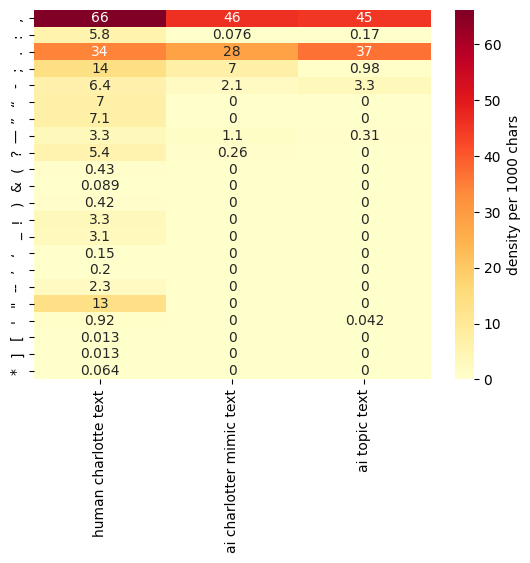

In [ ]:
charlotte_original_punctutation_density = punctutation_density(POS_tagging_charlotte_original)
charlotte_mimic_punctutation_density = punctutation_density(POS_tagging_charlotte_mimic)
topic_paragraph_punctutation_density = punctutation_density(POS_tagging_topic_paragraph)

print(charlotte_original_punctutation_density)
print(charlotte_mimic_punctutation_density)
print(topic_paragraph_punctutation_density)

density_dict = {
    "human charlotte text":charlotte_original_punctutation_density,
    "ai charlotter mimic text":charlotte_mimic_punctutation_density,
    "ai topic text":topic_paragraph_punctutation_density
}

heatmap_plotter(density_dict)


# charlotte_mimic_heatmap = heatmap_plotter(charlotte_mimic_punctutation_density)
# topic_paragraph_heatmap = heatmap_plotter(topic_paragraph_punctutation_density)
#


In [ ]:
def flesch_kincaid_grade_level(doc):
  total_syllables = [word._.syllables_count for word in doc if word.is_alpha and word._.syllables_count is not None]
  total_words = [word for word in doc if word.is_alpha]
  return 0.39 * (len(total_words) / len(list(doc.sents))) + 11.8 * (sum(total_syllables) / len(total_words) ) - 15.59

In [ ]:
total_syllables_human = [word._.syllables_count for word in POS_tagging_charlotte_original if word.is_alpha and word._.syllables_count is not None]
total_words_human = [word for word in POS_tagging_charlotte_original if word.is_alpha]

total_syllables_ai_mimic = [word._.syllables_count for word in POS_tagging_charlotte_mimic if word.is_alpha and word._.syllables_count is not None]
total_words_ai_mimic = [word for word in POS_tagging_charlotte_mimic if word.is_alpha]

total_syllables_topic = [word._.syllables_count for word in POS_tagging_topic_paragraph if word.is_alpha and word._.syllables_count is not None]
total_words_topic = [word for word in POS_tagging_topic_paragraph if word.is_alpha]

Flesch_Kincaid_human = 0.39 * (len(total_words_human) / len(list(POS_tagging_charlotte_original.sents))) + 11.8 * (sum(total_syllables_human) / len(total_words_human) ) - 15.59
print("Flesch_Kincaid_human : ",Flesch_Kincaid_human)

Flesch_Kincaid_ai_mimic = 0.39 * (len(total_words_ai_mimic)/ len(list(POS_tagging_charlotte_mimic.sents))) + 11.8 * (sum(total_syllables_ai_mimic) / len(total_words_ai_mimic)) - 15.59
print("Flesch_Kincaid_ai_mimic : ",Flesch_Kincaid_ai_mimic)

Flesch_Kincaid_topic = 0.39 * (len(total_words_topic) / len(list(POS_tagging_topic_paragraph.sents))) + 11.8 * (sum(total_syllables_topic) / len(total_words_topic)) - 15.59
print("Flesch_Kincaid_topic : ",Flesch_Kincaid_topic)

# Not a right metric honestly becuase doesnt track more essential metrics like the langugae just the syllables cant be a marker right


Flesch_Kincaid_human :  7.9855133542595205
Flesch_Kincaid_ai_mimic :  15.734811610038069
Flesch_Kincaid_topic :  15.10447532071385


# RANDOM FOREST

In [ ]:
!pip install spacy_syllables

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 15.2 MB/s eta 0:00:00


In [ ]:
!pip install shap

In [ ]:
import matplotlib.pyplot as plt
import nltk
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import spacy
nlp = spacy.load("en_core_web_sm")
from spacy_syllables import SpacySyllables
nlp.add_pipe("syllables", after="tagger")


In [ ]:
import torch
import torch.nn as nn

In [ ]:
def get_text_from_files(filepath):
  with open(filepath, "r") as f:
    file_contents = f.read()

  return file_contents


In [ ]:
def get_middle_50(n):
    mid = n // 2
    start = max(0, mid - 25)
    end = min(n, mid + 25)
    return start, end

In [ ]:
#Human text paragraphs
# Collecting data from all 4 books of charlotte bronte
# relative choosing to ensure proper contribution jane eyre and villete being bigger books get 32% contribution each and the others get 16% (Professor smallest) and 20%(Shirley)

# also test-train split 500 paragraphs we take 400 train 100 test so we use shirley for testing and the rest three for training
#Train set
jane_eyre = get_text_from_files("/content/Jane_eyre.txt")
jane_eyre_paragraphs = jane_eyre.split("\n\n")
jane_eyre_paragraphs = [paragraph for paragraph in jane_eyre_paragraphs if len(paragraph.split()) >= 80 and len(paragraph.split()) <= 220]
mid_start, mid_end = get_middle_50(len(jane_eyre_paragraphs))
jane_eyre_paragraphs = jane_eyre_paragraphs[:55] + jane_eyre_paragraphs[mid_start:mid_end]+jane_eyre_paragraphs[-55:]
print(len(jane_eyre_paragraphs))

villete_book = get_text_from_files("/content/Villete.txt")
villete_book_paragraphs = villete_book.split("\n\n")
villete_book_paragraphs = [paragraph for paragraph in villete_book_paragraphs if len(paragraph.split()) >= 80 and len(paragraph.split()) <= 220]
mid_start, mid_end = get_middle_50(len(villete_book_paragraphs))
villete_book_paragraphs = villete_book_paragraphs[:55] + villete_book_paragraphs[mid_start:mid_end]+villete_book_paragraphs[-55:]
print(len(villete_book_paragraphs))

professor_book = get_text_from_files("/content/Professor.txt")
professor_book_paragraphs = professor_book.split("\n\n")
professor_book_paragraphs = [paragraph for paragraph in professor_book_paragraphs if len(paragraph.split()) >= 80 and len(paragraph.split()) <= 220]
professor_book_paragraphs = professor_book_paragraphs[:40] + professor_book_paragraphs[-40:]
print(len(professor_book_paragraphs))


#Test set
shirley_book = get_text_from_files("/content/Shirley.txt")
shirley_book_paragraphs = shirley_book.split("\n\n")
shirley_book_paragraphs = [paragraph for paragraph in shirley_book_paragraphs if len(paragraph.split()) >= 80 and len(paragraph.split()) <= 220]
shirley_book_paragraphs = shirley_book_paragraphs[:50] + shirley_book_paragraphs[-50:]
print(len(shirley_book_paragraphs))


Human_Train_set = jane_eyre_paragraphs + villete_book_paragraphs + professor_book_paragraphs
Human_Test_set = shirley_book_paragraphs

print(len(Human_Train_set)," ", len(Human_Test_set))
# paragraphs = charlotte_original.split("\n\n")
# suitable_paragraphs = [paragraph for paragraph in paragraphs if len(paragraph.split()) >= 70 and len(paragraph.split()) <= 250]
# paragraphs = suitable_paragraphs
# print(len(paragraphs))
#

FileNotFoundError: [Errno 2] No such file or directory: '/content/Jane_eyre.txt'

In [ ]:
#AI Mimic Paragraphs

charlotte_mimic_paragraphs = get_text_from_files("/content/charlotte_paragraphs.txt")
paragraphs = charlotte_mimic_paragraphs.split("\n")
suitable_paragraphs = [paragraph for paragraph in paragraphs if len(paragraph.split()) >= 70 and len(paragraph.split()) <= 250]
paragraphs = suitable_paragraphs
print(len(paragraphs))

AI_mimic_train_set = paragraphs[:400]
AI_mimic_test_set = paragraphs[-100:]

print(len(AI_mimic_train_set)," ", len(AI_mimic_test_set))

500
400   100


In [ ]:
#AI Generic Paragraphs
#Note : the initially generated paragraph had only 445 paragraphs with proper word limit so I added one more run of the paragraph generation and added the same to this document in the end so that it doesnt disturb the flow in topics and gets added to the test set only
topic_paragraphs = get_text_from_files("/content/paragraphs.txt")
paragraphs = topic_paragraphs.split("\n")
suitable_paragraphs = [paragraph for paragraph in paragraphs if len(paragraph.split()) >= 78 and len(paragraph.split()) <= 230]
paragraphs = suitable_paragraphs

AI_generic_train_set = paragraphs[:400]
AI_generic_test_set = paragraphs[-100:]

print(len(AI_generic_train_set)," ", len(AI_generic_test_set))



400   100


In [ ]:
#feature extraction functions together





def calculate_ttr(doc):
  words = [token.text.lower() for token in doc if token.is_alpha]
  unique_words = set(words)
  ttr = len(unique_words) / len(words)
  return ttr


def hapax_toolkit(doc):
  words = [word.text.lower() for word in doc if word.is_alpha]
  freq = Counter(words)
  unique_words = [word for word, count in freq.items() if count == 1]
  hapax_rate = len(unique_words) / len(words)
  return hapax_rate

def adj_noun_ratio_evaluator(doc):
  adj_count = 0
  noun_count = 0
  for token in doc:
    if token.pos_ == "ADJ":
      adj_count += 1
    elif token.pos_ == "NOUN":
      noun_count += 1
  if(noun_count == 0):
    return 0
  return adj_count / noun_count


def depth_of_tree(node):
  if len(list(node.children)) == 0:
    return 0
  return 1+max(depth_of_tree(child) for child in node.children)

def average_depth(doc):
  depth_list = []
  for sent in doc.sents:
    depth_list.append(depth_of_tree(sent.root))

  return sum(depth_list) / len(depth_list)


def punctutation_density(doc):
  punctuation_count = {"em_dashes" : 0 , "semicolon": 0, "exclamation": 0, "other_punctuations" : 0}
  for token in doc:
    if token.is_punct:
      if(token.text == "—"):
        punctuation_count["em_dashes"] += 1
      elif(token.text == ";"):
        punctuation_count["semicolon"] += 1
      elif(token.text == "!"):
        punctuation_count["exclamation"] += 1
      else:
        punctuation_count["other_punctuations"] += 1
  total_tokens = len(doc)
  for punc in punctuation_count:
    punctuation_count[punc] = punctuation_count[punc] / total_tokens
  return punctuation_count


def flesch_kincaid_grade_level(doc):
  total_syllables = [word._.syllables_count for word in doc if word.is_alpha and word._.syllables_count is not None]
  total_words = [word for word in doc if word.is_alpha]
  return 0.39 * (len(total_words) / len(list(doc.sents))) + 11.8 * (sum(total_syllables) / len(total_words) ) - 15.59



In [ ]:
#Building feature file

def feature_row_builder(paragraph,class_id):
  features = {}
  paragraph_nlp = nlp(paragraph)
  features["paragraph"] = paragraph
  features["class_id"] = class_id
  features["ttr"] = calculate_ttr(paragraph_nlp)
  features["hapax_rate"] = hapax_toolkit(paragraph_nlp)
  features["adj_noun_ratio"] = adj_noun_ratio_evaluator(paragraph_nlp)
  features["average_depth"] = average_depth(paragraph_nlp)
  punctutation_density_map  = punctutation_density(paragraph_nlp)
  features["em_dash_density"] = punctutation_density_map["em_dashes"]
  features["semicolon_density"] = punctutation_density_map["semicolon"]
  features["exclamation_density"] = punctutation_density_map["exclamation"]
  features["other_punctuations_density"] = punctutation_density_map["other_punctuations"]
  features["flesch_kincaid_grade_level"] = flesch_kincaid_grade_level(paragraph_nlp)
  return features

In [ ]:
def feature_file_builder(paragraph_list,class_id):
  feature_file = []
  for paragraph in paragraph_list:
    feature_file.append(feature_row_builder(paragraph,class_id))
  return feature_file

In [ ]:
#Building feature

Human_Train_set_features = feature_file_builder(Human_Train_set,1)
AI_mimic_train_set_features = feature_file_builder(AI_mimic_train_set,2)
AI_generic_train_set_features = feature_file_builder(AI_generic_train_set,3)

Human_Test_set_features = feature_file_builder(Human_Test_set,1)
AI_mimic_test_set_features = feature_file_builder(AI_mimic_test_set,2)
AI_generic_test_set_features = feature_file_builder(AI_generic_test_set,3)

Train_set_features = Human_Train_set_features + AI_mimic_train_set_features + AI_generic_train_set_features
Test_set_features = Human_Test_set_features + AI_mimic_test_set_features + AI_generic_test_set_features




In [ ]:
Train_set_features_df = pd.DataFrame(Train_set_features)
Train_set_features_df.to_csv("Train_set_features.csv")
Test_set_features_df = pd.DataFrame(Test_set_features)
Test_set_features_df.to_csv("Test_set_features.csv")


NameError: name 'Train_set_features' is not defined

In [ ]:
with open("Train_set_features.csv", "r") as f:
  Train_set_features_df = pd.read_csv(f)

with open( "Test_set_features.csv", "r") as f:
  Test_set_features_df = pd.read_csv(f)

Train_set_features_df.drop("Unnamed: 0",axis=1,inplace=True)
Test_set_features_df.drop("Unnamed: 0",axis=1,inplace=True)

In [ ]:
Train_set_features_df.isnull().sum()
Test_set_features_df.isnull().sum()

,0
paragraph,0
class_id,0
ttr,0
hapax_rate,0
adj_noun_ratio,0
average_depth,0
em_dash_density,0
semicolon_density,0
exclamation_density,0
other_punctuations_density,0


In [ ]:
Train_set_features_df["class_id"].value_counts()

,count
class_id,
1,400
2,400
3,400


In [ ]:
X_train  = Train_set_features_df.drop(["paragraph","class_id"],axis = 1)
y_train = Train_set_features_df["class_id"]

X_test  = Test_set_features_df.drop(["paragraph","class_id"],axis = 1)
y_test = Test_set_features_df["class_id"]

In [ ]:
feature_columns = X_train.columns
Train_set_features_df.groupby("class_id")[feature_columns].mean()

,ttr,hapax_rate,adj_noun_ratio,average_depth,em_dash_density,semicolon_density,exclamation_density,other_punctuations_density,flesch_kincaid_grade_level
class_id,,,,,,,,,
1,0.700851,0.566648,0.409659,5.856960,0.005764,0.016071,0.002785,0.128041,12.016660
2,0.714973,0.614868,0.501576,7.884917,0.001170,0.006911,0.000000,0.076896,16.064152
3,0.774143,0.678022,0.563008,7.036411,0.000324,0.000986,0.000000,0.085305,15.202585


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd

rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)

y_pred = rfc.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: {:.2f}%".format(accuracy * 100))

Accuracy: 85.33%


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[97  2  1]
 [ 2 68 30]
 [ 1  8 91]]
              precision    recall  f1-score   support

           1       0.97      0.97      0.97       100
           2       0.87      0.68      0.76       100
           3       0.75      0.91      0.82       100

    accuracy                           0.85       300
   macro avg       0.86      0.85      0.85       300
weighted avg       0.86      0.85      0.85       300



In [ ]:
import pickle
filename = 'random_forest_model.pkl'
with open(filename, 'wb') as file:
    pickle.dump(rfc, file)


NameError: name 'rfc' is not defined

In [ ]:
import pickle
filename = 'random_forest_model.pkl'
rfc_model = pickle.load(open(filename, 'rb'))
result = rfc_model.score(X_test, y_test)
print(result)

0.8533333333333334


In [ ]:
import shap
explainer = shap.TreeExplainer(rfc)
shap_values = explainer.shap_values(X_test)
shap.initjs()

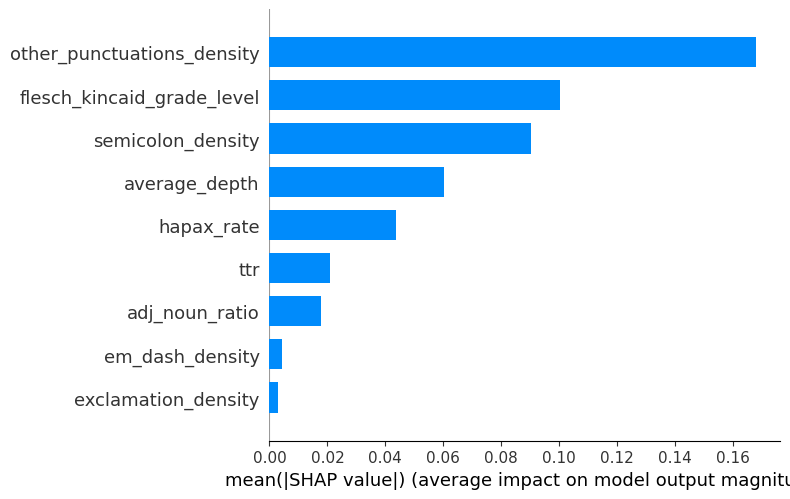

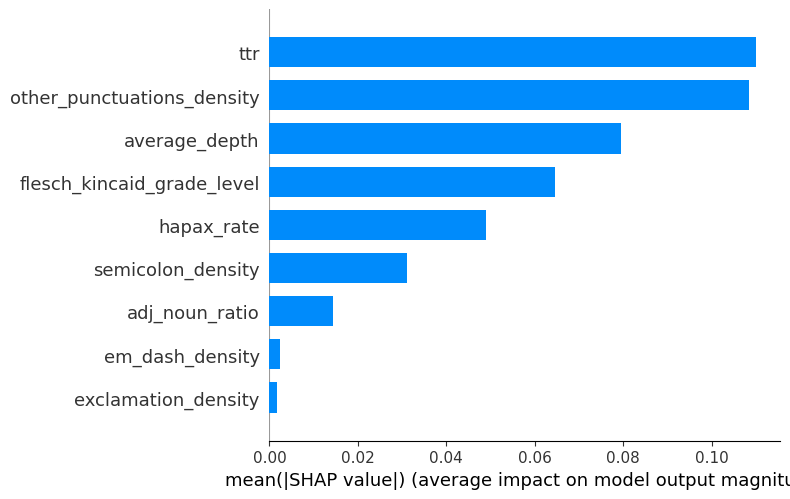

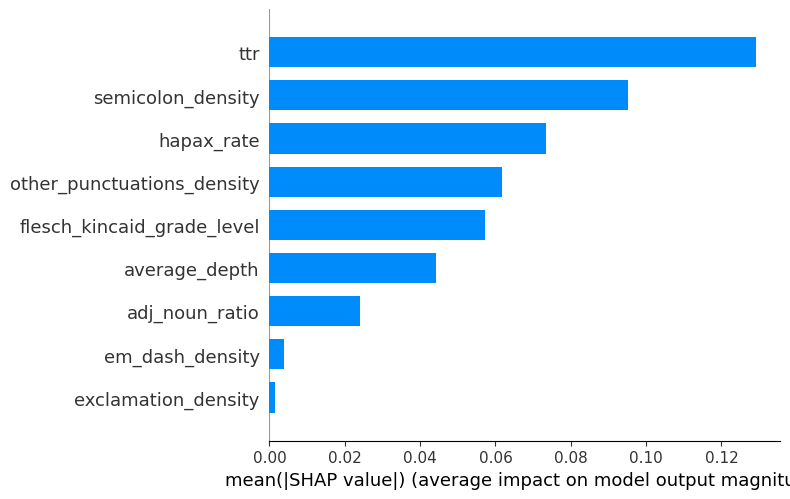

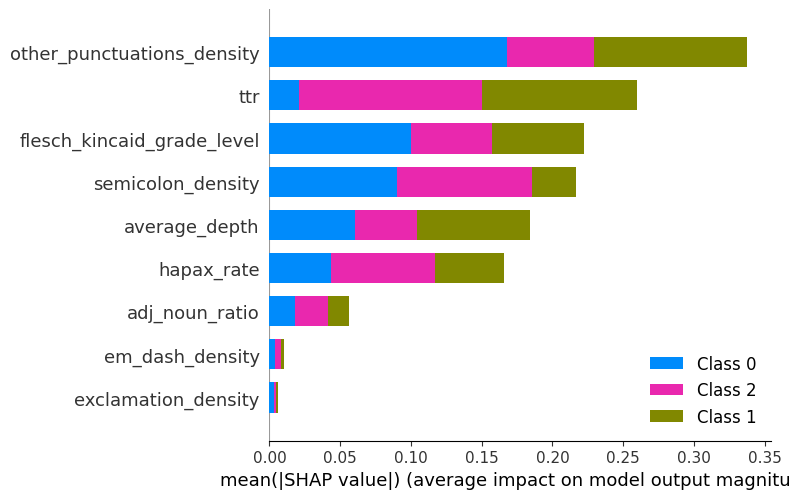

In [ ]:
#SHAP ANALYSIS

shap_values_class1 = shap_values[:, :, 0]
shap.summary_plot(shap_values_class1, X_test,plot_type="bar"
)
shap_values_class2 = shap_values[:, :, 1]
shap.summary_plot(shap_values_class2, X_test,plot_type="bar"
)
shap_values_class3 = shap_values[:, :, 2]
shap.summary_plot(shap_values_class3, X_test,plot_type="bar"
)
shap.summary_plot(shap_values, X_test,plot_type="bar"
)


# inference says the

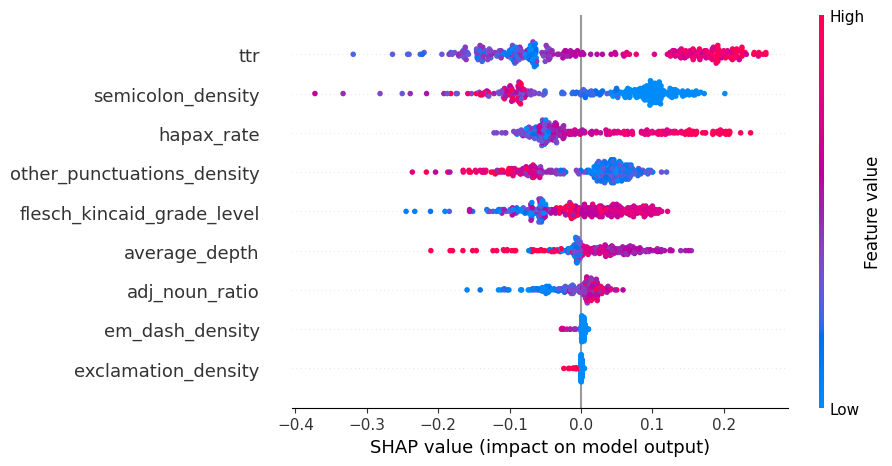

In [ ]:
explanation = explainer(X_test)
shap.plots.beeswarm(explanation[:,:,2])

## FeedForward NN

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 32.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd

from gensim.models import FastText

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [ ]:
from gensim.utils import tokenize
all_paragraph = Human_Train_set + AI_mimic_train_set + AI_generic_train_set
tokenized_train = [list(tokenize(paragraph)) for paragraph in all_paragraph]



In [ ]:
fasttext_model = FastText(
    sentences=tokenized_train,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=1,
    epochs=10,
    seed=42
)

In [ ]:
#so we have word representation models now we use it for building vector embeddings for our paragraphs

def paragraph_embeddings(paragraph,models):

  vector_embeddings = []

  for token in paragraph:
    if token.text in models.wv:
      vector_embeddings.append(models.wv[token.text])

  vector_embeddings = np.array(vector_embeddings)
  return np.mean(vector_embeddings,axis=0)


In [ ]:

embedding_table = []

for paragraph in all_paragraph:
  paragraph_tokens = nlp(paragraph)
  embedding_table.append(paragraph_embeddings(paragraph_tokens,fasttext_model))

X_Train = np.array(embedding_table)

In [ ]:
Y_Train = np.array([0]*len(Human_Train_set) + [1]*len(AI_mimic_train_set) + [2]*len(AI_generic_train_set))

In [ ]:
print(X_Train[0])
print(X_Train.shape)
print(Y_Train.shape)

[ 0.21196106  0.07901383 -0.04992253 -0.26987398 -0.01700754 -0.0729767
  0.32935068 -0.13960461  0.02231678  0.19750717 -0.04291169  0.05694874
  0.06149389  0.05155068  0.34730268 -0.02356953 -0.01811986 -0.17967984
  0.07423785  0.04749852  0.3725495  -0.17648795 -0.14364517 -0.06069317
  0.20797133  0.08183864 -0.08313189 -0.09804752 -0.20498951 -0.11718085
 -0.14336102  0.11624752 -0.04572252  0.08532097 -0.39562854  0.2766493
  0.27877918 -0.29681593 -0.04707295  0.00208221  0.44436768  0.04764937
  0.03880308 -0.02363118  0.13335545 -0.2868647  -0.10996332  0.26379818
 -0.04447254  0.0557204  -0.06006483 -0.25391144  0.0579404  -0.0030452
  0.23407719 -0.11244698 -0.19474395 -0.08272479 -0.37265494  0.21158421
  0.03615313  0.0384935  -0.25279066 -0.11294325  0.2123971   0.01652638
 -0.14617302 -0.17473869  0.03541992  0.30202797  0.0096962   0.18024087
  0.22194588 -0.13342975  0.01733595 -0.031201   -0.17813486  0.00422429
 -0.09530119 -0.15619026  0.0330541  -0.20216198  0.18

In [ ]:
embedding_table_test = []
all_test_paragraph = Human_Test_set + AI_mimic_test_set + AI_generic_test_set
for paragraph in all_test_paragraph:
  paragraph_tokens = nlp(paragraph)
  embedding_table_test.append(paragraph_embeddings(paragraph_tokens,fasttext_model))

X_Test = np.array(embedding_table_test)
Y_Test = np.array([0]*len(Human_Test_set) + [1]*len(AI_mimic_test_set) + [2]*len(AI_generic_test_set))

print(X_Test.shape)
print(Y_Test.shape)

(300, 100)
(300,)


In [ ]:
#Feedforward nn

import torch
import torch.nn as nn

In [ ]:
#input size 100, hidden 4*input size , out 3
class FeedForwardNN(nn.Module):
  def __init__(self, input_size, hidden_size, num_classes):
    super(FeedForwardNN, self).__init__()
    self.fc1 = nn.Linear(input_size, hidden_size)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(hidden_size, num_classes)

  def forward(self, x):
    out = self.fc1(x)
    out = self.relu(out)
    out = self.fc2(out)
    return out


In [ ]:

AI_Detection_Feed_Forward_model = FeedForwardNN(100,400,3)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(AI_Detection_Feed_Forward_model.parameters(), lr=0.005)

X_train_tensor = torch.tensor(X_Train, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_Train, dtype=torch.long)

X_test_tensor = torch.tensor(X_Test, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_Test, dtype=torch.long)



In [ ]:
epochs = 50

for epoch in range(epochs):

    AI_Detection_Feed_Forward_model.train()
    outputs = AI_Detection_Feed_Forward_model(X_train_tensor)
    loss = criterion(outputs, Y_train_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    predictions = torch.argmax(outputs, dim=1)

    accuracy = (
        (predictions == Y_train_tensor).float().mean()
    )

    if (epoch + 1) % 5 == 0:

        print(
            f"Epoch {epoch+1}/{epochs} "
            f"Loss: {loss.item():.4f} "
            f"Accuracy: {accuracy.item():.4f}"
        )

Epoch 5/50 Loss: 0.8238 Accuracy: 0.9258
Epoch 10/50 Loss: 0.5054 Accuracy: 0.9158
Epoch 15/50 Loss: 0.3407 Accuracy: 0.9358
Epoch 20/50 Loss: 0.2339 Accuracy: 0.9333
Epoch 25/50 Loss: 0.1796 Accuracy: 0.9342
Epoch 30/50 Loss: 0.1536 Accuracy: 0.9367
Epoch 35/50 Loss: 0.1355 Accuracy: 0.9450
Epoch 40/50 Loss: 0.1194 Accuracy: 0.9517
Epoch 45/50 Loss: 0.1048 Accuracy: 0.9558
Epoch 50/50 Loss: 0.0930 Accuracy: 0.9642


In [ ]:
AI_Detection_Feed_Forward_model.eval()

with torch.no_grad():

    test_outputs = AI_Detection_Feed_Forward_model(
        X_test_tensor
    )

    test_predictions = torch.argmax(
        test_outputs,
        dim=1
    )

In [ ]:
test_accuracy = (
    (test_predictions == Y_test_tensor)
    .float()
    .mean()
)

print("Test Accuracy:", test_accuracy.item())

Test Accuracy: 0.9566666483879089


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_true = Y_test_tensor.numpy()
y_pred = test_predictions.numpy()

print(confusion_matrix(y_true, y_pred))

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Class 1",
            "Class 2",
            "Class 3"
        ]
    )
)

[[99  1  0]
 [ 0 91  9]
 [ 0  3 97]]
              precision    recall  f1-score   support

     Class 1       1.00      0.99      0.99       100
     Class 2       0.96      0.91      0.93       100
     Class 3       0.92      0.97      0.94       100

    accuracy                           0.96       300
   macro avg       0.96      0.96      0.96       300
weighted avg       0.96      0.96      0.96       300



# LoRA Roberta finetuning

In [ ]:
!pip install --upgrade transformers tokenizers

In [ ]:
train_df = Train_set_features_df[["paragraph","class_id"]]
print(train_df.shape)
print(train_df.head())
print(train_df.iloc[0]['paragraph'])
test_df = Test_set_features_df[["paragraph","class_id"]]
print(test_df.shape)


(1200, 2)
                                           paragraph  class_id
0  The said Eliza, John, and Georgiana were now c...         1
1  Folds of scarlet drapery shut in my view to th...         1
2  Nor could I pass unnoticed the suggestion of t...         1
3  Each picture told a story; mysterious often to...         1
4  John Reed was a schoolboy of fourteen years ol...         1
The said Eliza, John, and Georgiana were now clustered round their mama in the drawing-room: she lay reclined on a sofa by the fireside, and with her darlings about her (for the time neither quarrelling nor crying) looked perfectly happy. Me, she had dispensed from joining the group; saying, “She regretted to be under the necessity of keeping me at a distance; but that until she heard from Bessie, and could discover by her own observation, that I was endeavouring in good earnest to acquire a more sociable and childlike disposition, a more attractive and sprightly manner—something lighter, franker, more na

In [ ]:
train_df['label'] = train_df['class_id'] - 1
test_df['label'] = test_df['class_id']  - 1

/tmp/ipykernel_5856/1075884314.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['label'] = train_df['class_id'] - 1
/tmp/ipykernel_5856/1075884314.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['label'] = test_df['class_id']  - 1


In [ ]:
print(train_df.head())

                                           paragraph  class_id  label
0  The said Eliza, John, and Georgiana were now c...         1      0
1  Folds of scarlet drapery shut in my view to th...         1      0
2  Nor could I pass unnoticed the suggestion of t...         1      0
3  Each picture told a story; mysterious often to...         1      0
4  John Reed was a schoolboy of fourteen years ol...         1      0


In [ ]:
print(train_df.iloc[1199]) #random testing 399,400,799,800,1199

paragraph    Power, ambition, and the concealment of feelin...
class_id                                                     3
label                                                        2
Name: 1199, dtype: object


In [ ]:
train_df.drop("class_id",axis=1,inplace=True)
test_df.drop("class_id",axis=1,inplace=True)

/tmp/ipykernel_5856/3963630525.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.drop("class_id",axis=1,inplace=True)
/tmp/ipykernel_5856/3963630525.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.drop("class_id",axis=1,inplace=True)


In [ ]:
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["label"]
)
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(960, 2)
(240, 2)
(300, 2)


In [ ]:
print(val_df.iloc[-50]) #random testing 399,400,799,800,1199

paragraph    Power and its limits become glaringly apparent...
label                                                        2
Name: 1183, dtype: object


In [ ]:
from transformers import RobertaTokenizer

roberta_tokenizer = RobertaTokenizer.from_pretrained("FacebookAI/roberta-base", force_download=True)
print(roberta_tokenizer.tokenize("The said Eliza, John, and Georgiana were now clustered"))

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

['The', 'Ġsaid', 'ĠEl', 'iza', ',', 'ĠJohn', ',', 'Ġand', 'ĠGeorg', 'iana', 'Ġwere', 'Ġnow', 'Ġclustered']


In [ ]:
train_encodings = roberta_tokenizer(
    train_df["paragraph"].tolist(),
    padding="max_length",
    truncation=True,
    max_length=300,
    return_tensors="pt"
)

val_encodings = roberta_tokenizer(
    val_df["paragraph"].tolist(),
    padding="max_length",
    truncation=True,
    max_length=300,
    return_tensors="pt"
)

test_encodings = roberta_tokenizer(
    test_df["paragraph"].tolist(),
    padding="max_length",
    truncation=True,
    max_length=300,
    return_tensors="pt"
)

In [ ]:
print(roberta_tokenizer.decode(train_encodings["input_ids"][0]))

<s>The authority of conscience remains an inconvenient and tyrannical master for one who lacks the fortune to support its high demands; a conscience that speaks with the voice of absolute truth while the stomach clamors for pragmatic compromise; a moral imperative that condemns every profitable dishonesty yet offers no substitute for the bread it forbids us to earn. I watched my contemporaries slide gracefully down the path of least resistance, trimming their principles to fit the prevailing wind of advantage, while I clung stubbornly to my useless rectitude like a shipwrecked sailor holding to a sinking spar. The cost of this integrity was measured in closed doors, lowered eyes, and the quiet contempt of those who had successfully made terms with the world. Yet to have abandoned that inner monitor would have been to commit a murder far more final than any physical crime; the quiet strangulation of the self by the self. I chose the path of ostracism and penury, finding in the unbroken 

In [ ]:
train_labels = torch.tensor(train_df["label"].tolist(), dtype=torch.int64)
test_labels = torch.tensor(test_df["label"].tolist(), dtype=torch.int64)
val_labels = torch.tensor(val_df["label"].tolist(), dtype=torch.int64)

In [ ]:
import torch
class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
train_Dataset = Dataset(train_encodings,train_labels)
val_Dataset = Dataset(val_encodings,val_labels)
test_Dataset =  Dataset(test_encodings,test_labels)

In [ ]:
# Define a function that can print the trainable parameters
def print_number_of_trainable_model_parameters(model):
    trainable_model_params = 0
    all_model_params = 0
    for _, param in model.named_parameters():
        all_model_params += param.numel()
        if param.requires_grad:
            trainable_model_params += param.numel()
    return f"trainable model parameters: {trainable_model_params}\nall model parameters: {all_model_params}\npercentage of trainable model parameters: {100 * trainable_model_params / all_model_params:.2f}%"


In [ ]:
from transformers import RobertaForSequenceClassification
model = RobertaForSequenceClassification.from_pretrained("FacebookAI/roberta-base",num_labels=3)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
!pip install -q peft transformers accelerate datasets

In [ ]:
import peft

lora_config = peft.LoraConfig(
    r=8,
    lora_alpha=32,
    lora_dropout=0.1,
    bias="none",
    target_modules=["query", "key","value"],
    task_type="SEQ_CLS")


In [ ]:
print_number_of_trainable_model_parameters(model)

'trainable model parameters: 124647939\nall model parameters: 124647939\npercentage of trainable model parameters: 100.00%'

In [ ]:
model

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [ ]:
pip install --upgrade torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 12.2 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [ ]:
from peft import (
    LoraConfig,
    get_peft_model,
    TaskType,
    PeftModel
)

peft_model = get_peft_model(model,
                            lora_config)


In [ ]:
peft_model

PeftModelForSequenceClassification(
  (base_model): LoraModel(
    (model): RobertaForSequenceClassification(
      (roberta): RobertaModel(
        (embeddings): RobertaEmbeddings(
          (word_embeddings): Embedding(50265, 768, padding_idx=1)
          (token_type_embeddings): Embedding(1, 768)
          (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (position_embeddings): Embedding(514, 768, padding_idx=1)
        )
        (encoder): RobertaEncoder(
          (layer): ModuleList(
            (0-11): 12 x RobertaLayer(
              (attention): RobertaAttention(
                (self): RobertaSelfAttention(
                  (query): lora.Linear(
                    (base_layer): Linear(in_features=768, out_features=768, bias=True)
                    (lora_dropout): ModuleDict(
                      (default): Dropout(p=0.1, inplace=False)
                    )
                    (lora_A): ModuleD

In [ ]:
print_number_of_trainable_model_parameters(peft_model)

'trainable model parameters: 1035267\nall model parameters: 125683206\npercentage of trainable model parameters: 0.82%'

In [ ]:
import numpy as np
import sklearn
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
model.config.problem_type = "single_label_classification"

In [ ]:
from transformers import TrainingArguments, Trainer

peft_training_args = TrainingArguments(
    output_dir="./roberta_lora_results",
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-4,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_strategy="epoch",
    report_to="none"
)


peft_trainer = Trainer(
    model=peft_model,
    args=peft_training_args,
    train_dataset= train_Dataset,
    eval_dataset= val_Dataset,
    compute_metrics=compute_metrics,
)

peft_trainer.train()


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/tmp/ipykernel_5856/3277646492.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_5856/3277646492.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item["labels"] = torch.tensor(self.labels[idx])
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss


In [ ]:
import torch
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from peft import PeftModel

device = "cuda:0" if torch.cuda.is_available() else "cpu"


adapter_path = "/content/Roberta_pretrained_model"

base_model = RobertaForSequenceClassification.from_pretrained(
    "FacebookAI/roberta-base", num_labels=3
)

roberta_tokenizer = RobertaTokenizer.from_pretrained(adapter_path)

peft_model = PeftModel.from_pretrained(base_model, adapter_path)
peft_model.to(device)
peft_model.eval()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


PeftModelForSequenceClassification(
  (base_model): LoraModel(
    (model): RobertaForSequenceClassification(
      (roberta): RobertaModel(
        (embeddings): RobertaEmbeddings(
          (word_embeddings): Embedding(50265, 768, padding_idx=1)
          (token_type_embeddings): Embedding(1, 768)
          (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (position_embeddings): Embedding(514, 768, padding_idx=1)
        )
        (encoder): RobertaEncoder(
          (layer): ModuleList(
            (0-11): 12 x RobertaLayer(
              (attention): RobertaAttention(
                (self): RobertaSelfAttention(
                  (query): lora.Linear(
                    (base_layer): Linear(in_features=768, out_features=768, bias=True)
                    (lora_dropout): ModuleDict(
                      (default): Dropout(p=0.1, inplace=False)
                    )
                    (lora_A): ModuleD

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import numpy as np


test_output = peft_trainer.predict(test_Dataset)

test_logits = test_output.predictions
test_preds = np.argmax(test_logits, axis=-1)


test_labels = test_Dataset.labels.numpy()


accuracy = accuracy_score(test_labels, test_preds)

precision, recall, f1, _ = precision_recall_fscore_support(
    test_labels,
    test_preds,
    average="weighted",
    zero_division=0
)

print("TEST RESULTS")
print("=" * 40)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")

print("\nTrue label distribution:")
print(np.bincount(test_labels))

print("\nPredicted label distribution:")
print(np.bincount(test_preds))

print("\nConfusion Matrix:")
print(confusion_matrix(test_labels, test_preds))

/tmp/ipykernel_604/3277646492.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_604/3277646492.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item["labels"] = torch.tensor(self.labels[idx])


TEST RESULTS
Accuracy:  0.9833
Precision: 0.9841
Recall:    0.9833
F1:        0.9833

True label distribution:
[100 100 100]

Predicted label distribution:
[100  95 105]

Confusion Matrix:
[[100   0   0]
 [  0  95   5]
 [  0   0 100]]


In [ ]:
import torch
import shap

text = """Chronic loneliness acts as a slow-burning fire within the human body, triggering persistent physiological stress responses that elevate blood pressure, increase systemic inflammation, and disrupt healthy sleep patterns. Over time, this chronic isolation degrades cardiovascular health and weakens immune function, posing a physical toll comparable to smoking fifteen cigarettes a day. Psychologically, the absence of meaningful connection erodes cognitive resilience, accelerates mental fatigue, and intensifies the risk of anxiety and clinical depression. This creates a self-reinforcing cycle where emotional withdrawal dampens social engagement, leaving individuals trapped in a state of profound alienation that diminishes both their quality of life and overall longevity."""

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

peft_model.to(device)
peft_model.eval()

def predict(texts):

    inputs = roberta_tokenizer(
        list(texts),
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = peft_model(**inputs)

    probabilities = torch.softmax(outputs.logits, dim=-1)

    return probabilities.cpu().numpy()



probabilities = predict([text])

prediction = probabilities[0].argmax()

print("Predicted class:", prediction)
print("Probabilities:", probabilities)

explainer = shap.Explainer(
    predict,
    shap.maskers.Text(roberta_tokenizer)
)

shap_values = explainer([text])
shap.plots.text(shap_values[0, :, prediction])

Predicted class: 2
Probabilities: [[1.2625203e-06 1.5245222e-04 9.9984622e-01]]


  0%|          | 0/498 [00:00<?, ?it/s]


PartitionExplainer explainer: 2it [07:42, 462.78s/it]              


In [ ]:
import torch
import shap


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

peft_model.to(device)
peft_model.eval()

def predict(texts):

    inputs = roberta_tokenizer(
        list(texts),
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = peft_model(**inputs)

    probabilities = torch.softmax(outputs.logits, dim=-1)

    return probabilities.cpu().numpy()


explainer = shap.Explainer(
        predict,
        shap.maskers.Text(roberta_tokenizer)
    )

def analyser(text):
    probabilities = predict([text])

    prediction = probabilities[0].argmax()
    print("Text:",text)
    print("Predicted class:", prediction)
    print("Probabilities:", probabilities)

    shap_values = explainer([text])
    shap.plots.text(shap_values[0, :, prediction])

In [ ]:

#analyser

Jane_austen_text =" Why, my dear, you must know, Mrs. Long says that Netherfield is taken by a young man of large fortune from the north of England; that he came down on Monday in a chaise and four to see the place, and was so much delighted with it that he agreed with Mr. Morris immediately; that he is to take possession before Michaelmas, and some of his servants are to be in the house by the end of next week."

charles_dickens_text = "Among other public buildings in a certain town, which for many reasons it will be prudent to refrain from mentioning, and to which I will assign no fictitious name, there is one anciently common to most towns, great or small: to wit, a workhouse; and in this workhouse was born: on a day and date which I need not trouble myself to repeat, inasmuch as it can be of no possible consequence to the reader, in this stage of the business at all events: the item of mortality whose name is prefixed to the head of this chapter."

harry_potter_text = "There will be no foolish wand-waving or silly incantations in this class. As such, I don't expect many of you to appreciate the subtle science and exact art that is potion-making. However, for those select few who possess the predisposition, I can teach you how to bewitch the mind and ensnare the senses. I can tell you how to bottle fame, brew glory, and even put a stopper in death. Then again, maybe some of you have come to Hogwarts in possession of abilities so formidable that you feel confident enough to not pay attention!"

research_paper = "The reader is encouraged to read Diffie and Hellman’s excellent article [1] for further background, for elaboration of the concept of a public-key cryptosystem, and for a discussion of other problems in the area of cryptography. The ways in which a public-key cryptosystem can ensure privacy and enable signatures (described in Sections III and IV below) are also due to Diffie and Hellman."

# texts = [Jane_austen_text,charles_dickens_text,harry_potter_text,]
analyser(research_paper)


Predicted class: 2
Probabilities: [[0.00257192 0.01218361 0.9852445 ]]


  0%|          | 0/498 [00:00<?, ?it/s]


PartitionExplainer explainer: 2it [02:46, 166.13s/it]              


In [ ]:
text = "Guiding this internal chaos is the stern authority of conscience, that unblinking magistrate whose verdicts brook no appeal and whose standards know no human weakness. When the world calls me mad for refusing its easy compromises, this internal voice whispers its quiet justification, turning public scorn into an honorable badge of endurance. It is a lonely master to serve, demanding total obedience and offering no earthly reward save the cold comfort of an unspotted record before the bar of eternity."
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

inputs = roberta_tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=128
)


inputs = {k: v.to(device) for k, v in inputs.items()}

model.eval()

with torch.no_grad():
    outputs = peft_model(**inputs)
    logits = outputs.logits
    prediction = torch.argmax(logits, dim=-1).item()

print("Predicted class:", prediction)
print("Logits:", logits.cpu().numpy())

Predicted class: 1
Logits: [[-4.5596533  5.5006757 -1.3491881]]


Genetic Algorithm

In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np
from prettytable import PrettyTable

In [ ]:
def fitness_function(text):
    probabilities = predict([text])
    human_score = probabilities[0][0]
    return human_score

In [ ]:
def build_gemini_style_paragraph_prompt_for_GA(topics, num_of_paragraphs):
  return f"""
### Instruction:
You are a long-form content generator producing a dataset {num_of_paragraphs} paragraphs. You must strictly follow the response format rules below — violating them breaks an automated parser downstream.

CRITICAL RESPONSE FORMAT RULES (highest priority, must never be violated):
1. Output ONLY a single valid JSON object. Nothing else.
2. Do NOT include any preamble, explanation, acknowledgment, or closing remarks (e.g., no "Here is your JSON", no "I hope this helps").
3. Do NOT wrap the JSON in markdown code fences (no ```json or ```).
4. Do NOT include titles, headers, bullet points, or numbering inside any paragraph text.
5. The output must match this EXACT schema, with these exact keys:

{{
  "paragraphs": [
    {{"paragraph": "<text of paragraph 1>"}},
    {{"paragraph": "<text of paragraph 2>"}},
    ...
    {{"paragraph": "<text of paragraph 10>"}}
  ],
}}

- "paragraphs" must contain EXACTLY {num_of_paragraphs} objects, each with a single key "paragraph".

STYLE RULES (write every paragraph in this voice — highest priority alongside format rules):
- First-person, confessional narration — speak with intimate directness, at times addressing the reader as though speaking to a confidant rather than a distant audience.
- Long, complex sentences built with semi-colons — unspool a single thought across clauses, reaching and curling back on itself, rather than breaking it into short sentences.
- Think-on-the-page narration: narrate the thought process in real time as it unfolds, rather than summarizing conclusions after the fact.
- Filter everything through the narrator's subjective consciousness — events, settings, and other people exist only as the narrator perceives and judges them.
- Combine vivid, highly detailed visual description of landscapes and settings with restrained internal dialogue.
- Realism paired with quiet acceptance — hardship and constraint are faced steadily, never resolved melodramatically.
- Introspective language — frequent self-examination of the narrator's own emotional and moral state.
- Latinate English interspersed with occasional French expressions, lending a formal, educated register.
- Do NOT use modern idioms, casual phrasing, or contemporary vocabulary — maintain a 19th-century literary register throughout.

STYLE EXAMPLES (imitate the SENTENCE CONSTRUCTION, RHYTHM, AND VOICE below — NOT the content, characters, or subject matter; these examples exist purely to demonstrate sentence-level style):

Example 1: "They were not bound to regard with affection a thing that could not sympathize with one amongst them; a heterogeneous thing, opposed to them in temperament, in capacity, in propensities; a useless thing, incapable of serving their interest, or adding to their pleasure; a noxious thing, cherishing the germs of indignation at their treatment, at contempt of their judgement."

Example 2: "I complexly felt that he was of a different nature from me; that his humanitas was not my humanitas; that he was a man of the world, a man of action, a man of code and system, and that I was none of these things. I knew that he looked down on me from a height of intellectual superiority, which he took no pains to conceal; and that he regarded my mind as a piece of raw material, which it was his duty to fashion and polish according to his own notions."

Note the technique demonstrated above: repeated parallel clause structures separated by semi-colons, each restating or intensifying the previous clause from a slightly different angle ("a heterogeneous thing... a useless thing... a noxious thing"; "that his... was not my...; that he was...; and that I was..."). Apply this same rhetorical layering technique — anaphora-like repetition of a clause structure with semi-colon separation, building cumulative intensity — to the TOPICS given below, using entirely different subject matter, characters, and content than the examples.

CONTENT RULES:
- Topics for this batch: {topics}
- There has to be exactly 10 objects in the result
- Each paragraph has to be strictly from a different topic. There should not be any repetition of topics.
- Paragraphs must be standalone (do not use phrases like "as discussed above," "continuing from before," or "as mentioned earlier"), but must be thematically and tonally linked to each other and to the prior context, so the batch reads as a coherent continuation.
- DEDUPLICATION RULE (strict): No two paragraphs, either within this batch or compared against the prior context summary, may start with the same or a near-identical opening sentence structure. Vary sentence openers, paragraph structures, and rhetorical approaches throughout.
- Do not repeat specific phrases, analogies, or examples already used in the prior context summary; introduce new angles, examples, or framing while staying thematically consistent.
- Do NOT copy any phrases, sentences, or content from the STYLE EXAMPLES above — those exist only to demonstrate technique, and reusing their wording would be plagiarism, not style transfer.


### Input:
TOPICS: {topics}

### Response:

"""

In [ ]:
from pydantic import BaseModel, Field
from typing import List
import json, time
class GA_Paragraph(BaseModel):
    paragraph: str = Field(description="A single paragraph with 100-200 words.")

class GA_BatchOutput(BaseModel):
    paragraphs: List[GA_Paragraph] = Field(min_length=10, max_length=10,description="Exactly 10 paragraphs.")

class GA_Mutation_BatchOutput(BaseModel):
    paragraphs: List[GA_Paragraph] = Field(min_length=3, max_length=3,description="Exactly 3 paragraphs.")

In [ ]:
def call_gemini_for_GA(prompt, response_format):
  try:
      print("calling gemini")
      interaction = client.interactions.create(
        model="gemini-3.5-flash-lite",
        input= prompt,
        response_format = response_format,
        generation_config={
          "thinking_level": "low"
      },
        )
      result = interaction.output_text
      print("Result generated")
      return result
  except Exception as e:
      raise RuntimeError(f"Error calling the functionE{e}")



In [ ]:
topics = [
    "The Cost of Moral Integrity",
    "The Search for Belonging",
    "The Ethics of Dependency",
    "Class and the Boundaries of Love",
    "Faith and Desire",
    "The Authority of Conscience",
    "The Isolation of the Foreigner",
    "The Concealment of Feeling",
    "The Divided Self",
    "Faith Under Foreign Custom",
    "The Fragility of Fulfillment",
    "The Ethics of Ambition",
    "Intellect Versus Fortune",
    "Kinship and Betrayal",
    "The Dignity of Labor",
    "Rivalry in Courtship",
    "The Desperation of Poverty",
    "Power and Its Limits",
    "Loyalty Under Romantic Strain",
    "Grief and Public Composure",
    "The Uncertainty of Justice",
]

In [ ]:
def create_initial_population(size):
    population = []
    try:
      all_paragraphs= []
      output_path = "GA_initial_population.json"

      prompt = build_gemini_style_paragraph_prompt_for_GA(topics, size)
      print("Prompt generated")

      response_format = {
            "type": "text",
            "mime_type": "application/json",
            "schema": GA_BatchOutput.model_json_schema()
        }

      result = call_gemini_for_GA(prompt,response_format)

      if len(result.paragraphs) >= 10:
          result.paragraphs = result.paragraphs[:10]
      elif len(result.paragraphs) < 10:
          raise ValueError(f"Expected 10 paragraphs, got {len(result.paragraphs)}")

      all_paragraphs.extend([p.paragraph for p in result.paragraphs])
      print("Generated successfully")
      print(len(all_paragraphs))

      with open(output_path, "w") as f:
                json.dump({"paragraphs": all_paragraphs}, f, indent=2)
      time.sleep(10)

      return result
    except Exception as e:
      raise RuntimeError(f"Error calling the functionE{e}")




In [ ]:
def selection(population, fitnesses):
    sorted_set = sorted(zip(population, fitnesses), key=lambda x: x[1], reverse=True)
    selected = [text for (text,fitness) in sorted_set[:3]]
    return selected

In [112]:
def mutation(population):
    MUTATION_STRATEGIES = [
      "Rewrite to change sentence rhythm and length while keeping vocabulary the same.",
      "Introduce one subtle grammatical inconsistency or one rare archaic word.",
      "Vary punctuation usage — add or remove semicolons, dashes, or comma placement.",
      "Rewrite using more Latinate vocabulary and formal register.",
  ]
    mutated_population = []
    current_stratergy = random.choice(MUTATION_STRATEGIES)
    print("Selected strategy:", current_stratergy)
    mutation_prompt = f"""
### Instruction
You are a 19th century English author. You use {current_stratergy} to
rewrite the paragraph you receive. Perform the task below and give the response
strictly following the response format.

### RESPONSE CONTENT RULES(very important)

1) Retain the meaning of the paragraph.
2) Each paragraph has to be rewritten and given a individual object
3) DON'T LEAVE OUT ANY PARAGRAPH

### CRITICAL RESPONSE FORMAT RULES (highest priority, must never be violated):
1. Output ONLY a single valid JSON object. Nothing else.
2. Do NOT include any preamble, explanation, acknowledgment, or closing remarks.
3. Do NOT wrap the JSON in markdown code fences.
4. Do NOT include titles, headers, bullet points, or numbering inside any paragraph text.
5. The output must match this EXACT schema, with these exact keys:

{{
    "paragraphs": [
        {{"paragraph": "<rewritten text of paragraph 1>"}},
        {{"paragraph": "<rewritten text of paragraph 2>"}},
        {{"paragraph": "<rewritten text of paragraph 3>"}}
    ]
}}

### INPUT

PARAGRAPHS: {population}
STRATERGY: {current_stratergy}

### RESPONSE
"""

    response_format = {
        "type": "text",
        "mime_type": "application/json",
        "schema": GA_Mutation_BatchOutput.model_json_schema()
    }

    result = call_gemini_for_GA(
        mutation_prompt,
        response_format
    )
    result = GA_Mutation_BatchOutput.model_validate_json(result)
    print(result)
    if len(result.paragraphs) >= 3:
        result.paragraphs = result.paragraphs[:3]
    else:
        raise ValueError(
            f"Expected 3 paragraphs, got {len(result.paragraphs)}"
        )

    mutated_population.extend(
        [p.paragraph for p in result.paragraphs]
    )

    print("Generated successfully")
    print("Number of mutated paragraphs:", len(mutated_population))

    return mutated_population


In [ ]:
 def json_to_txt(self,json_file_path, txt_file_path):

        if not os.path.isfile(json_file_path):
            print(f"File {json_file_path} does not exist.")
            return

        with open(json_file_path, 'r') as json_file:
            data = json.load(json_file)

        with open(txt_file_path, 'w') as txt_file:
            for item in data.get("paragraphs", []):
                txt_file.write(f"{item}\n")

        print(f"Converted {json_file_path} to {txt_file_path}.")

In [67]:
import os

file_path = "/content/GA_initial_population.json"
if os.path.isfile(file_path):
  with open(file_path, 'r') as file:
    population = json.load(file)
else:
  print("File not found")
  population = create_initial_population(10)

fitnesses = [fitness_function(text) for text in population["paragraphs"]]
selected = selection(population['paragraphs'], fitnesses)
# mutated = mutation(selected)


In [68]:
print(fitnesses)
print(len(selected))

[np.float32(0.005388513), np.float32(0.00081565726), np.float32(0.0005548922), np.float32(0.011638985), np.float32(0.0005517026), np.float32(0.0011158049), np.float32(0.00041927613), np.float32(0.0002739802), np.float32(9.467769e-05), np.float32(0.0002072208)]
3


In [93]:
#First mutation
mutated_file_path = "/content/GA_mutated_population.json"
mutated = mutation(selected)
with open(mutated_file_path, "w") as f:
        json.dump({"paragraphs": mutated}, f, indent=2)


calling gemini
Result generated
paragraphs=[GA_Paragraph(paragraph="The insurmountable wall that divides the station of my beloved from my own humble obscurity has risen before us with all the cold finality of an ancient rampart, guarded by the vigilant sentinels of pedigree and estate. We may speak of affection transcending earthly ranks in the seclusion of the garden walk, yet when confronted with the austere gaze of her family, the romantic illusion dissolves into the harsh light of social reality. I see plainly in their calculated civilities the unstated conviction that love cannot bridge a gulf measured in title-deeds and ancestral portraits; they view my devotion not as a noble passion, but as an intolerable presumption, an illicit trespass across sacred boundaries. She, poor girl, attempts to navigate this cruel dilemma with a gentle, tearful loyalty, yet I perceive the slow erosion of her spirit under the relentless pressure of their expectations and her own inherited habits of

In [94]:
#First mutation result
file_path = "/content/GA_mutated_population.json"
if os.path.isfile(file_path):
  with open(file_path, 'r') as file:
    population = json.load(file)
else:
  print("File not found")
  population = create_initial_population(10)

fitnesses = [fitness_function(text) for text in population["paragraphs"]]
selected = selection(population['paragraphs'], fitnesses)
# mutated = mutation(selected)


In [103]:
mutated_batch_file_path = "/content/GA_mutated_batch_results.json"
mutation_batch_results = []
mutation_result = []
for i in range(len(population["paragraphs"])):
  entry = { "gen_paragraph": population["paragraphs"][i], "fitness": fitnesses[i]}
  mutation_result.append(entry)

mutation_batch_entry = {
    "mutation_batch" : 1,
    "batch_entry": mutation_result
}
mutation_batch_results.append(mutation_batch_entry)







In [95]:
print(fitnesses)

[np.float32(0.011638985), np.float32(0.005388513), np.float32(0.0011158049)]


In [113]:
mutated_file_path = "/content/GA_mutated_population"
for i in range(10):
  mutated = mutation(selected)
  mutated_file_path = f"/content/GA_mutated_population{i}.json"
  with open(mutated_file_path, "w") as f:
        json.dump({"paragraphs": mutated}, f, indent=2)
  print(mutated)
  fitnesses = [fitness_function(text) for text in mutated]
  selected = selection(mutated, fitnesses)


Selected strategy: Vary punctuation usage — add or remove semicolons, dashes, or comma placement.
calling gemini
Result generated
paragraphs=[GA_Paragraph(paragraph='Behold—the insurmountable barrier which doth eternally sunder the lofty station of my adored from mine own lowly and obscure estate—hath arisen betwixt us with the chilling finality of some immemorial rampart; defended by the ever-vigilant warders of lineage and broad acres. Verily, we may discourse upon a tender penchant transcending worldly degrees whilst wandering amidst sequestered garden paths; yet upon encountering the austere countenances of her kin, this romantic phantasm straightway evaporates beneath the glaring illumination of societal truth. I perceive full well within their calculated courtesies the tacit persuasion that mere affection can never span a chasm computed in ancient parchments and ancestral canvases; indeed, they regard my fervent devotion not as an honorable passion, but rather as an audacious tre

In [114]:
print(fitnesses)

[np.float32(0.07567293), np.float32(0.029877637), np.float32(0.0006180239)]


In [115]:
!zip -r all_files.zip *


  adding: GA_initial_population.json (deflated 55%)
  adding: GA_mutated_batch_results.json (deflated 46%)
  adding: GA_mutated_population0.json (deflated 50%)
  adding: GA_mutated_population1.json (deflated 52%)
  adding: GA_mutated_population2.json (deflated 50%)
  adding: GA_mutated_population3.json (deflated 50%)
  adding: GA_mutated_population4.json (deflated 50%)
  adding: GA_mutated_population5.json (deflated 50%)
  adding: GA_mutated_population6.json (deflated 50%)
  adding: GA_mutated_population7.json (deflated 50%)
  adding: GA_mutated_population8.json (deflated 50%)
  adding: GA_mutated_population9.json (deflated 50%)
  adding: GA_mutated_population.json (deflated 50%)
  adding: roberta_lora_results/ (stored 0%)
  adding: Roberta_pretrained_model/ (stored 0%)
  adding: Roberta_pretrained_model/adapter_config.json (deflated 58%)
  adding: Roberta_pretrained_model/adapter_model.safetensors (deflated 7%)
  adding: Roberta_pretrained_model/tokenizer.json (deflated 82%)
  adding:

In [118]:
paragraphs = []
for i in range(10):
  mutated_file_path = f"/content/GA_mutated_population{i}.json"
  with open(mutated_file_path, 'r') as file:
    paragraphs_list = json.load(file)
  paragraphs.extend(paragraphs_list["paragraphs"])
print(paragraphs)


['Behold—the insurmountable barrier which doth eternally sunder the lofty station of my adored from mine own lowly and obscure estate—hath arisen betwixt us with the chilling finality of some immemorial rampart; defended by the ever-vigilant warders of lineage and broad acres. Verily, we may discourse upon a tender penchant transcending worldly degrees whilst wandering amidst sequestered garden paths; yet upon encountering the austere countenances of her kin, this romantic phantasm straightway evaporates beneath the glaring illumination of societal truth. I perceive full well within their calculated courtesies the tacit persuasion that mere affection can never span a chasm computed in ancient parchments and ancestral canvases; indeed, they regard my fervent devotion not as an honorable passion, but rather as an audacious trespass across consecrated bounds. She, poor gentle soul, doth strive to thread this cruel labyrinth with sorrowful fealty; yet mine eyes discern the gradual wasting 

In [120]:
fitness = [fitness_function(text) for text in paragraphs]
print(fitness)
print(len(fitness))


[np.float32(0.1396752), np.float32(0.025995784), np.float32(0.016535211), np.float32(0.016601332), np.float32(0.22499041), np.float32(0.00045349007), np.float32(0.015074322), np.float32(0.043552276), np.float32(0.0009376692), np.float32(0.027727703), np.float32(0.035163753), np.float32(0.001040643), np.float32(0.021724382), np.float32(0.03450983), np.float32(0.0008915266), np.float32(0.03450983), np.float32(0.021724382), np.float32(0.0008915266), np.float32(0.03450983), np.float32(0.021724382), np.float32(0.0008915266), np.float32(0.03450983), np.float32(0.021724382), np.float32(0.0008915266), np.float32(0.029877637), np.float32(0.07567293), np.float32(0.0006180239), np.float32(0.07567293), np.float32(0.029877637), np.float32(0.0006180239)]
30


In [121]:
selected_top_3 =  selection(paragraphs, fitnesses)

In [122]:
print(selected_top_3)

['Behold—the insurmountable barrier which doth eternally sunder the lofty station of my adored from mine own lowly and obscure estate—hath arisen betwixt us with the chilling finality of some immemorial rampart; defended by the ever-vigilant warders of lineage and broad acres. Verily, we may discourse upon a tender penchant transcending worldly degrees whilst wandering amidst sequestered garden paths; yet upon encountering the austere countenances of her kin, this romantic phantasm straightway evaporates beneath the glaring illumination of societal truth. I perceive full well within their calculated courtesies the tacit persuasion that mere affection can never span a chasm computed in ancient parchments and ancestral canvases; indeed, they regard my fervent devotion not as an honorable passion, but rather as an audacious trespass across consecrated bounds. She, poor gentle soul, doth strive to thread this cruel labyrinth with sorrowful fealty; yet mine eyes discern the gradual wasting 

In [123]:
fitness_top = [fitness_function(text) for text in selected_top_3]
print(fitness_top)

[np.float32(0.1396752), np.float32(0.025995784), np.float32(0.016535211)]
